# Intro2Astro Week 3 — Exploring Exoplanets with the NASA Exoplanet Archive

## Kepler vs TESS demo + mass–radius assignment

Today we will use real data from the **NASA Exoplanet Archive** to ask a simple question:

> **Do Kepler and TESS find the same kinds of planets?**

This notebook is designed for a short live demonstration plus one take-home assignment. You do not need to be an astronomy major or a Python expert. The goal is to learn how real scientific archives can help us see patterns — and biases — in what we know about exoplanets.

## Learning goals

By the end, you should be able to:

- Load an Exoplanet Archive table into Python.
- Select planets discovered by Kepler and TESS.
- Make a period–radius diagram.
- Explain why Kepler and TESS samples look different.
- Recognize the small-planet **radius valley**.

## 0. Big picture: Kepler and TESS

Both Kepler and TESS use the **transit method**: they look for tiny dips in a star's brightness when a planet passes in front of it.

But their survey strategies are different:

- **Kepler** stared deeply at one patch of sky for years.
- **TESS** surveys almost the whole sky and focuses on bright, nearby stars.

So even though they use a similar detection method, they do not necessarily find exactly the same kinds of planets.

## 1. Setup

We will use three common Python libraries:

- `pandas` for working with tables;
- `numpy` for numerical tools;
- `matplotlib` for plotting.

In [ ]:
import os
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12

## 2. Load the Exoplanet Archive data

The data file in this folder was downloaded from the NASA Exoplanet Archive **Planetary Systems Composite Parameters** table.

The code below searches the `data/` folder for a file whose name starts with `PSCompPars`.

In [6]:
candidate_files = sorted(glob.glob(os.path.join("data", "PSCompPars_*.csv")))

if len(candidate_files) == 0:
    raise FileNotFoundError("No PSCompPars CSV file found in the data/ folder.")

DATA_FILE = candidate_files[-1]
print(f"Using data file: {DATA_FILE}")

df = pd.read_csv(DATA_FILE, comment="#")

print(f"Number of planet rows: {len(df):,}")
print(f"Number of columns: {len(df.columns):,}")
df.head()

Using data file: data/PSCompPars_2026.07.15_05.17.55.csv
Number of planet rows: 6,319
Number of columns: 84


,pl_name,hostname,sy_snum,sy_pnum,discoverymethod,disc_year,disc_facility,pl_controv_flag,pl_orbper,pl_orbpererr1,...,sy_disterr2,sy_vmag,sy_vmagerr1,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2
0,11 Com b,11 Com,2,1,Radial Velocity,2007,Xinglong Station,0,323.21000,0.06,...,-1.9238,4.72307,0.023,-0.023,2.282,0.346,-0.346,4.44038,0.003848,-0.003848
1,11 UMi b,11 UMi,1,1,Radial Velocity,2009,Thueringer Landessternwarte Tautenburg,0,516.21997,3.20,...,-1.9765,5.01300,0.005,-0.005,1.939,0.270,-0.270,4.56216,0.003903,-0.003903
2,14 And b,14 And,1,1,Radial Velocity,2008,Okayama Astrophysical Observatory,0,186.76000,0.11,...,-0.7140,5.23133,0.023,-0.023,2.331,0.240,-0.240,4.91781,0.002826,-0.002826
3,14 Her b,14 Her,1,2,Radial Velocity,2002,W. M. Keck Observatory,0,1766.41000,0.67,...,-0.0073,6.61935,0.023,-0.023,4.714,0.016,-0.016,6.38300,0.000351,-0.000351
4,16 Cyg B b,16 Cyg B,3,1,Radial Velocity,1996,Multiple Observatories,0,798.50000,1.00,...,-0.0111,6.21500,0.016,-0.016,4.651,0.016,-0.016,6.06428,0.000603,-0.000603


### Columns we will use today

| Column | Meaning | Unit |
|---|---|---|
| `pl_name` | Planet name | — |
| `disc_facility` | Discovery facility or mission | — |
| `pl_orbper` | Orbital period | days |
| `pl_rade` | Planet radius | Earth radii |
| `pl_bmasse` | Planet mass | Earth masses |
| `pl_bmassprov` | Mass provenance | — |

A blank value usually means “not measured” or “not available,” not zero.

In [7]:
useful_columns = ["pl_name", "disc_facility", "pl_orbper", "pl_rade", "pl_bmasse", "pl_bmassprov"]
df[useful_columns].head(10)

,pl_name,disc_facility,pl_orbper,pl_rade,pl_bmasse,pl_bmassprov
0,11 Com b,Xinglong Station,323.21000,12.200,4914.898486,Msini
1,11 UMi b,Thueringer Landessternwarte Tautenburg,516.21997,12.300,4684.814200,Msini
2,14 And b,Okayama Astrophysical Observatory,186.76000,13.100,1131.151301,Msini
3,14 Her b,W. M. Keck Observatory,1766.41000,12.500,2828.672822,Mass
4,16 Cyg B b,Multiple Observatories,798.50000,13.500,565.737400,Msini
5,17 Sco b,Lick Observatory,578.38000,12.900,1373.018718,Msini
6,18 Del b,Okayama Astrophysical Observatory,982.85000,12.500,2926.246143,Msini
7,1RXS J160929.1-210524 b,Gemini Observatory,NaN,18.647,3000.000000,Mass
8,24 Boo b,Okayama Astrophysical Observatory,30.33000,13.900,280.642483,Msini
9,24 Sex b,Lick Observatory,452.80000,13.400,632.460000,Msini


## 3. Select Kepler and TESS planets

For this demo, we will use:

- original Kepler planets: `disc_facility == "Kepler"`
- TESS planets: `disc_facility == "Transiting Exoplanet Survey Satellite (TESS)"`

We will also keep only planets that have both orbital period and radius measurements.

In [8]:
# Keep planets with the two measurements needed for the period-radius diagram.
period_radius = df.dropna(subset=["pl_orbper", "pl_rade"]).copy()


kepler_planets = period_radius[period_radius["disc_facility"] == "Kepler"].copy()
tess_planets = period_radius[
    period_radius["disc_facility"] == "Transiting Exoplanet Survey Satellite (TESS)"
].copy()

print(f"Kepler planets with period and radius: {len(kepler_planets):,}")
print(f"TESS planets with period and radius: {len(tess_planets):,}")

Kepler planets with period and radius: 2,780
TESS planets with period and radius: 904


## 4. Figure 1: period–radius diagrams

A planet's **orbital period** tells us how long it takes to orbit its star. A planet's **radius** tells us its size.

We will compare Kepler and TESS using the same axis limits, so the two panels are directly comparable.

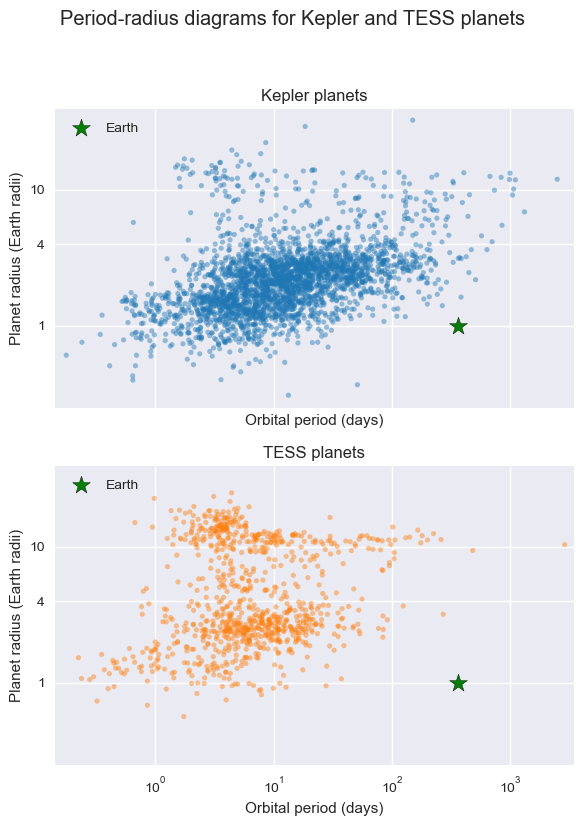

In [9]:
# Shared axis limits make the comparison fair.
xmin = min(kepler_planets["pl_orbper"].min(), tess_planets["pl_orbper"].min())
xmax = max(kepler_planets["pl_orbper"].max(), tess_planets["pl_orbper"].max())
ymin = min(kepler_planets["pl_rade"].min(), tess_planets["pl_rade"].min())
ymax = max(kepler_planets["pl_rade"].max(), tess_planets["pl_rade"].max())

fig, axes = plt.subplots(2, 1, figsize=(6, 8), sharex=True, sharey=True)

samples = [
    (kepler_planets, "Kepler", "tab:blue"),
    (tess_planets, "TESS", "tab:orange"),
]

for ax, (sample, title, color) in zip(axes, samples):
    ax.scatter(sample["pl_orbper"], sample["pl_rade"], s=14, alpha=0.45, color=color, edgecolor="none",zorder=10)
    ax.scatter(365.25, 1.0, s=180, marker="*", color="green", edgecolor="black", label="Earth")
    ax.set_xscale("log") 
    ax.set_yscale("log")
    ax.set_xlim(xmin * 0.8, xmax * 1.2)
    ax.set_ylim(ymin * 0.8, ymax * 1.2)
    ax.set_title(f"{title} planets")
    ax.set_ylabel("Planet radius (Earth radii)")
    ax.set_xlabel("Orbital period (days)")
    ax.legend(loc="upper left")
    ax.set_yticks([1,4,10])
    ax.set_yticklabels([1,4,10])
    
fig.suptitle("Period-radius diagrams for Kepler and TESS planets", y=1.03)
fig.tight_layout()
plt.show()


- Which regions are crowded?
- Which regions are sparse?
- Where is Earth compared with the confirmed exoplanets?
- Do sparse regions mean planets are rare, difficult to detect, or both?

Important idea: a planet catalog reflects both **what exists** and **what our telescopes are good at finding**.

# Take-home assignment: explore the radius valley

Your goal is to take the radius-valley plot from the live demo and explore it more carefully.

The radius valley is a dip in the number of planets around roughly 1.5–2.0 Earth radii. It may mark a transition between smaller rocky super-Earths and larger sub-Neptunes with thicker atmospheres.

## Assignment

1. Recreate the Kepler vs TESS radius histogram.
2. Change one plotting choice:
   - try different bin widths;
   - use raw counts instead of normalized density;
   - focus on only Kepler planets;
   - focus on only TESS planets;
   - change the radius range, for example 0.8–4 Earth radii.
3. Write a short interpretation:
   - Is the radius valley visible?
   - Is it easier to see in Kepler or TESS?
   - How does your plotting choice affect what you see?
   - Could the feature be astrophysical, observational, or both?

In [ ]:
radius_min = 0.5
radius_max = 6.0
bins = np.linspace(radius_min, radius_max, 50)

kepler_small = kepler_planets[
    (kepler_planets["pl_rade"] >= radius_min) &
    (kepler_planets["pl_rade"] <= radius_max)
]

tess_small = tess_planets[
    (tess_planets["pl_rade"] >= radius_min) &
    (tess_planets["pl_rade"] <= radius_max)
]

plt.figure(figsize=(9, 5))

plt.hist(
    kepler_small["pl_rade"],
    bins=bins,
    density=True,
    alpha=0.55,
    label=f"Kepler (N={len(kepler_small):,})",
    color="tab:blue",
)

plt.hist(
    tess_small["pl_rade"],
    bins=bins,
    density=True,
    alpha=0.55,
    #histtype='step',
    label=f"TESS (N={len(tess_small):,})",
    color="tab:orange",
)

plt.axvspan(1.7, 2.0, color="gray", alpha=0.18, label="Approx. radius valley")

plt.xlabel("Planet radius (Earth radii)")
plt.ylabel("Normalized number of planets")
plt.title("Small-planet radius distributions: Kepler vs TESS")
plt.legend()
plt.show()